In [90]:
using VeryDiff, LinearAlgebra, Plots, JLD2, SpecialFunctions
using VeryDiff: LayeredModel, to_layered_model, ONNXChebyshevPoly
import VeryDiff: approximate_polynomial_iterative

using VNNLib
const OXP = VNNLib.OnnxParser

using VeryDiffPolyExperiments
using VeryDiffPolyExperiments: generate_poly_network

# Code for Storing and Sharing Networks

To keep the format simple, a neural network with linear layers and Chebyshev polynomial layers will be stored as a list of tuples:

```
[("linear", W1, b1), ("chebyshev", coeffs1, l1, u1), ("linear", W2, b2), ("chebyshev", coeffs1, l1, u1), ...]
```

These lists can be saved and loaded again using the following code:
```julia

using JLD2

net = ...
list_of_tuples = convert_to_list_of_tuples(net)

@save "/path/to/file.jld2" params=list_of_tuples

list_of_tuples = load("/path/to/file.jld2")["params"]
```

In [14]:
function convert_to_list_of_tuples(net::LayeredModel)
    layers = []
    for layer in net.layers
        if layer isa OXP.ONNXLinear
            push!(layers, ("linear", layer.dense.weight, layer.dense.bias))
        elseif layer isa ONNXChebyshevPoly
            push!(layers, ("chebyshev", layer.coeffs, layer.l, layer.u))
        elseif layer isa OXP.ONNXRelu
            push!(layers, ("relu",))
        elseif layer isa OXP.ONNXGelu
            push!(layers, ("gelu",))
        else
            error("Unsupported layer type: $(typeof(layer))")
        end
    end
    return layers
end

convert_to_list_of_tuples (generic function with 1 method)

# Code for Merging Normalization into Layer

In [3]:
function merge_normalization_into_dense(layer_lin::OXP.ONNXLinear, layer_poly::ONNXChebyshevPoly{S,N,VN}) where {S,N,VN}
    l, u = layer_poly.l, layer_poly.u

    a = 1 ./ (0.5 .* (u .- l))
    b = -0.5 .* (u .+ l) ./ (0.5 .* (u .- l))

    Ŵ = a .* layer_lin.dense.weight
    b̂ = a .* layer_lin.dense.bias .+ b

    n = length(l)
    return OXP.ONNXLinear(layer_lin.inputs, layer_lin.outputs, layer_lin.name, Ŵ, b̂, double_precision=true), 
           ONNXChebyshevPoly(layer_poly.inputs, layer_poly.outputs, layer_poly.name, layer_poly.coeffs, -ones(N, n), ones(N, n))
end

merge_normalization_into_dense (generic function with 1 method)

In [10]:
function merge_normalization_into_dense(net::LayeredModel{S}) where S
    layers = net.layers
    new_layers = Vector{OXP.Node{S}}(undef, length(layers))

    for i in 1:2:length(layers) - 1
        layer_lin = layers[i]
        layer_poly = layers[i + 1]
        layer_lin_new, layer_poly_new = merge_normalization_into_dense(layer_lin, layer_poly)
        new_layers[i] = layer_lin_new
        new_layers[i + 1] = layer_poly_new
    end

    if isodd(length(layers))
        new_layers[end] = layers[end]
    end

    return LayeredModel(new_layers)
end

merge_normalization_into_dense (generic function with 2 methods)

# Construct GeLU Networks

In [16]:
using VeryDiffPolyExperiments: load_mnist_data, acc_fun, max_fun, mae_fun, mse_fun, evaluate_network

In [27]:
VeryDiff.ALMOST_ZERO_LEADING_COEFF_WARNING[] = false

false

In [17]:
X_test, y_labels = load_mnist_data()
y_labels = y_labels .+ 1;  # convert to 1-based indexing

In [42]:
function compute_approximation_stats(nn, degrees; max_polys_per_layer=1, max_iter=0, verbosity=0)
    ŷ = [nn(x) for x in X_test]
    ŷ = hcat(ŷ...)'
    original_acc = acc_fun(y_labels, ŷ)
    println("Original accuracy: $original_acc")

    max_errs_single = []
    maes_single = []
    mses_single = []
    accs_single = []

    degrees = 1:1:100
    for d in degrees
        nn_poly = approximate_polynomial_iterative(nn, Zonotope(zeros(784), ones(784)), d, max_polys_per_layer=max_polys_per_layer, verbosity=verbosity, max_iter=max_iter)
        max_err, mae, mse, acc, _ = evaluate_network(nn_poly, X_test, ŷ, y_labels, max_fun, mae_fun, mse_fun, acc_fun)
        push!(max_errs_single, max_err)
        push!(maes_single, mae)
        push!(mses_single, mse)
        push!(accs_single, acc)
        println("Degree $d: max err = $max_err, mae = $mae, mse = $mse, acc = $acc")
    end

    return max_errs_single, maes_single, mses_single, accs_single
end

compute_approximation_stats (generic function with 1 method)

In [26]:
onnx_model = load_onnx_model("../networks/mnist/mnist_gelu_256x4_2e5.onnx")
nn = to_layered_model(onnx_model);

┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/qVmgT/src/network/layered_network.jl:21


In [29]:
ŷ = [nn(x) for x in X_test]
ŷ = hcat(ŷ...)'
original_acc = acc_fun(y_labels, ŷ)
println("Original accuracy: $original_acc")

max_errs_single = []
maes_single = []
mses_single = []
accs_single = []

degrees = 1:1:100
for d in degrees
    nn_poly = approximate_polynomial_iterative(nn, Zonotope(zeros(784), ones(784)), d, max_polys_per_layer=1, verbosity=0, max_iter=0)
    max_err, mae, mse, acc, _ = evaluate_network(nn_poly, X_test, ŷ, y_labels, max_fun, mae_fun, mse_fun, acc_fun)
    push!(max_errs_single, max_err)
    push!(maes_single, mae)
    push!(mses_single, mse)
    push!(accs_single, acc)
    println("Degree $d: max err = $max_err, mae = $mae, mse = $mse, acc = $acc")
end

Original accuracy: 0.9936
Degree 1: max err = 430.703952756014, mae = 413.2909598444243, mse = 377224.30488591985, acc = 0.10441666666666667
Degree 2: max err = 58.85077468506101, mae = 43.6023479757018, mse = 7417.826829639171, acc = 0.3298
Degree 3: max err = 107.0535140521591, mae = 90.54382962459002, mse = 20119.983555810533, acc = 0.10441666666666667
Degree 4: max err = 73.29833437671405, mae = 58.35296401171594, mse = 14809.524347067096, acc = 0.21291666666666667
Degree 5: max err = 71.33720324873602, mae = 55.67339616154418, mse = 9260.536226813165, acc = 0.11481666666666666
Degree 6: max err = 69.79311558239606, mae = 55.14466039812748, mse = 12996.629149881133, acc = 0.28475
Degree 7: max err = 41.100428812531334, mae = 28.02974416331745, mse = 2324.800417677015, acc = 0.18186666666666668
Degree 8: max err = 63.60089639792898, mae = 49.23874573789177, mse = 10026.232686491432, acc = 0.3895166666666667
Degree 9: max err = 40.5430655193549, mae = 28.431151456341134, mse = 3381.1

In [32]:
onnx_model = load_onnx_model("../networks/mnist/mnist_256x4_2e5.onnx")
nn_relu = to_layered_model(onnx_model);

┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/qVmgT/src/network/layered_network.jl:21


In [34]:
ŷ = [nn_relu(x) for x in X_test]
ŷ = hcat(ŷ...)'
original_acc = acc_fun(y_labels, ŷ)
println("Original accuracy: $original_acc")

max_errs_relu_single = []
maes_relu_single = []
mses_relu_single = []
accs_relu_single = []

degrees = 1:1:100
for d in degrees
    nn_relu_poly = approximate_polynomial_iterative(nn_relu, Zonotope(zeros(784), ones(784)), d, max_polys_per_layer=1, verbosity=0, max_iter=1)
    max_err, mae, mse, acc, _ = evaluate_network(nn_relu_poly, X_test, ŷ, y_labels, max_fun, mae_fun, mse_fun, acc_fun)
    push!(max_errs_relu_single, max_err)
    push!(maes_relu_single, mae)
    push!(mses_relu_single, mse)
    push!(accs_relu_single, acc)
    println("Degree $d: max err = $max_err, mae = $mae, mse = $mse, acc = $acc")
end

Original accuracy: 0.9940333333333333
Degree 1: max err = 153.1204767244745, mae = 133.23056254450455, mse = 74265.605976892, acc = 0.16381666666666667
Degree 2: max err = 118.35236386522759, mae = 99.7960039134421, mse = 46610.49653760462, acc = 0.11681666666666667
Degree 3: max err = 98.64513497159616, mae = 79.86615900181215, mse = 29990.582181887243, acc = 0.09035
Degree 4: max err = 74.90433549814307, mae = 60.75040716915916, mse = 17511.24851693552, acc = 0.1316
Degree 5: max err = 91.00509978361843, mae = 73.65284528696506, mse = 26260.390408954572, acc = 0.09035
Degree 6: max err = 57.21062538274455, mae = 44.40999744029255, mse = 9226.799019089718, acc = 0.12456666666666667
Degree 7: max err = 75.23236606628745, mae = 59.335767378228944, mse = 17105.05684977454, acc = 0.09038333333333333
Degree 8: max err = 59.61074732775323, mae = 47.3888007092494, mse = 11716.525627683239, acc = 0.09306666666666667
Degree 9: max err = 58.29693185864767, mae = 44.13985771297317, mse = 9454.24

In [38]:
onnx_model = load_onnx_model("../networks/mnist/mnist_gelu_256x4_1e4.onnx")
nn_gelu_1e4 = to_layered_model(onnx_model);
max_errs_gelu_1e4, maes_gelu_1e4, mses_gelu_1e4, accs_gelu_1e4 = compute_approximation_stats(nn_gelu_1e4, degrees; max_polys_per_layer=1, max_iter=0, verbosity=0)

Original accuracy: 0.9893


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/qVmgT/src/network/layered_network.jl:21


Degree 1: max err = 110.8728118618029, mae = 97.70757040494975, mse = 25438.888295673576, acc = 0.17165
Degree 2: max err = 25.94426412365846, mae = 12.580393699238794, mse = 375.750847065472, acc = 0.11751666666666667
Degree 3: max err = 32.56100079459445, mae = 20.985456930995216, mse = 1412.6667501132376, acc = 0.12128333333333334
Degree 4: max err = 26.627371699764506, mae = 13.982271605326106, mse = 533.4873066285475, acc = 0.11371666666666666
Degree 5: max err = 22.744872462428184, mae = 14.19563283472382, mse = 535.1997449057435, acc = 0.17301666666666668
Degree 6: max err = 23.84843990764593, mae = 12.92307640266356, mse = 451.8716327298347, acc = 0.1174
Degree 7: max err = 18.451966138472493, mae = 10.63613123745569, mse = 251.9864794079829, acc = 0.2783333333333333
Degree 8: max err = 21.204482754714405, mae = 11.581944771783864, mse = 349.45208891826894, acc = 0.12803333333333333
Degree 9: max err = 18.319208360140756, mae = 9.926581037129495, mse = 193.6119961820765, acc = 

(Any[110.8728118618029, 25.94426412365846, 32.56100079459445, 26.627371699764506, 22.744872462428184, 23.84843990764593, 18.451966138472493, 21.204482754714405, 18.319208360140756, 18.61406583769094  …  1.1463979636469919, 1.2403203931674787, 1.449583322170799, 0.7381224690058571, 1.6897586304096013, 0.7018835000930004, 1.6362466747761042, 0.589248373265991, 1.3436247343883263, 0.7827840930713545], Any[97.70757040494975, 12.580393699238794, 20.985456930995216, 13.982271605326106, 14.19563283472382, 12.92307640266356, 10.63613123745569, 11.581944771783864, 9.926581037129495, 10.413457013182688  …  0.5339506483383969, 0.774246021613058, 0.7920282114053596, 0.3825635062845652, 1.0145030991176867, 0.22852742856406763, 1.0535023437452498, 0.2708453456867784, 0.8511711609167746, 0.41827550857062035], Any[25438.888295673576, 375.750847065472, 1412.6667501132376, 533.4873066285475, 535.1997449057435, 451.8716327298347, 251.9864794079829, 349.45208891826894, 193.6119961820765, 264.5470129203881

In [43]:
onnx_model = load_onnx_model("../networks/mnist/mnist_256x4_1e4.onnx")
nn_relu_1e4 = to_layered_model(onnx_model);
max_errs_relu_1e4, maes_relu_1e4, mses_relu_1e4, accs_relu_1e4 = compute_approximation_stats(nn_relu_1e4, degrees; max_polys_per_layer=1, max_iter=1, verbosity=0)

Original accuracy: 0.9864166666666667


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/qVmgT/src/network/layered_network.jl:21


Degree 1: max err = 83.01271935594941, mae = 70.29011955604699, mse = 22712.02437210584, acc = 0.11055
Degree 2: max err = 43.5920284106266, mae = 30.627664717350257, mse = 3965.6470847915807, acc = 0.13633333333333333
Degree 3: max err = 42.64112256946862, mae = 32.05868088292125, mse = 4162.260871121947, acc = 0.26038333333333336
Degree 4: max err = 28.20467298967098, mae = 17.696939431269566, mse = 1035.7282648507623, acc = 0.22656666666666667
Degree 5: max err = 34.82434593281417, mae = 25.344770590784563, mse = 2360.8553488293906, acc = 0.3243
Degree 6: max err = 26.708920636359288, mae = 17.550554917989476, mse = 995.6492355504448, acc = 0.3351166666666667
Degree 7: max err = 25.91797299653859, mae = 17.016330719786854, mse = 880.698481207074, acc = 0.55275
Degree 8: max err = 25.938168097073763, mae = 17.67720757168126, mse = 1003.4902987597675, acc = 0.3930666666666667
Degree 9: max err = 20.895432830231474, mae = 13.319196424252882, mse = 413.58124034289324, acc = 0.6346833333

(Any[83.01271935594941, 43.5920284106266, 42.64112256946862, 28.20467298967098, 34.82434593281417, 26.708920636359288, 25.91797299653859, 25.938168097073763, 20.895432830231474, 23.002325554353334  …  2.8630838778066647, 3.7513141647085106, 2.1444040241861186, 4.090858357178872, 1.6589480249224362, 3.6877367166573594, 2.2238649801238024, 2.7276196887290487, 2.709537765955328, 1.6190569320943893], Any[70.29011955604699, 30.627664717350257, 32.05868088292125, 17.696939431269566, 25.344770590784563, 17.550554917989476, 17.016330719786854, 17.67720757168126, 13.319196424252882, 15.419863915298484  …  1.4080969074820096, 1.6457975977651658, 0.8005827988488665, 2.040835001203466, 0.6152369415697642, 1.7737121527435207, 0.8162146844623887, 1.0708482801698844, 1.2142890282754883, 0.4779277235770432], Any[22712.02437210584, 3965.6470847915807, 4162.260871121947, 1035.7282648507623, 2360.8553488293906, 995.6492355504448, 880.698481207074, 1003.4902987597675, 413.58124034289324, 724.5327028205049

In [47]:
onnx_model = load_onnx_model("../networks/mnist/mnist_gelu_256x4.onnx")
nn_gelu = to_layered_model(onnx_model);
max_errs_gelu, maes_gelu, mses_gelu, accs_gelu = compute_approximation_stats(nn_gelu, degrees; max_polys_per_layer=1, max_iter=0, verbosity=0)

Original accuracy: 0.9984833333333333


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/qVmgT/src/network/layered_network.jl:21


Degree 1: max err = 5110.757637948671, mae = 5074.1645277295565, mse = 1.1021071435626638e8, acc = 0.10441666666666667
Degree 2: max err = 6482.679137822725, mae = 6319.647324581401, mse = 1.4711976650672725e8, acc = 0.10441666666666667
Degree 3: max err = 3963.6785560098238, mae = 3902.0139359550226, mse = 7.040185301464623e7, acc = 0.10218333333333333
Degree 4: max err = 7354.273263131251, mae = 7120.405325935058, mse = 2.0431779409805277e8, acc = 0.10441666666666667
Degree 5: max err = 4890.956143280195, mae = 4777.788570155802, mse = 1.095446679432253e8, acc = 0.10218333333333333
Degree 6: max err = 6795.254192576848, mae = 6648.6218462985, mse = 1.8942755464629564e8, acc = 0.12481666666666667
Degree 7: max err = 678.8068577539299, mae = 601.9747196597407, mse = 1.1482568175226187e6, acc = 0.20926666666666666
Degree 8: max err = 6747.684262316212, mae = 6644.694602833193, mse = 2.047706492040847e8, acc = 0.10218333333333333
Degree 9: max err = 3320.2979913637487, mae = 3195.7325466

(Any[5110.757637948671, 6482.679137822725, 3963.6785560098238, 7354.273263131251, 4890.956143280195, 6795.254192576848, 678.8068577539299, 6747.684262316212, 3320.2979913637487, 5774.890869554051  …  274.015312161133, 718.1443795436603, 580.232848158357, 582.0182921360299, 706.888837824156, 249.30297200112747, 735.5488727305756, 252.85233670116088, 724.6614860100954, 546.8975298179439], Any[5074.1645277295565, 6319.647324581401, 3902.0139359550226, 7120.405325935058, 4777.788570155802, 6648.6218462985, 601.9747196597407, 6644.694602833193, 3195.7325466426373, 5670.333377110876  …  175.96003872638303, 686.4539892605195, 473.5680653452411, 550.61476527661, 646.8306740847693, 209.76478670122486, 695.4777952234035, 170.0825690339561, 691.358713006293, 427.3689534643543], Any[1.1021071435626638e8, 1.4711976650672725e8, 7.040185301464623e7, 2.0431779409805277e8, 1.095446679432253e8, 1.8942755464629564e8, 1.1482568175226187e6, 2.047706492040847e8, 3.995318426301501e7, 1.5793038140254492e8  … 

In [48]:
onnx_model = load_onnx_model("../networks/mnist/mnist-net_256x4.onnx")
nn_relu_standard = to_layered_model(onnx_model);
max_errs_relu_standard, maes_relu_standard, mses_relu_standard, accs_relu_standard = compute_approximation_stats(nn_relu_standard, degrees; max_polys_per_layer=1, max_iter=1, verbosity=0)

┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/qVmgT/src/network/layered_network.jl:21


Original accuracy: 0.99085
Degree 1: max err = 1.7151591128246197, mae = 1.2347985003288577, mse = 2.5495160226860167, acc = 0.11236666666666667
Degree 2: max err = 3156.28133823102, mae = 2579.7615088527996, mse = 1.7168309443989478e7, acc = 0.09915
Degree 3: max err = 3267.483389458493, mae = 2726.6960197517574, mse = 1.8201447283568956e7, acc = 0.09915
Degree 4: max err = 2407.762595940729, mae = 1848.3841838168964, mse = 8.106099548743516e6, acc = 0.09915
Degree 5: max err = 6063.382090859888, mae = 5367.920235528969, mse = 7.718162709044e7, acc = 0.09915
Degree 6: max err = 1541.4026358030617, mae = 1388.573968071309, mse = 4.55847760246206e6, acc = 0.09751666666666667
Degree 7: max err = 7701.893692553661, mae = 6983.983791412582, mse = 1.3617458729628417e8, acc = 0.09915
Degree 8: max err = 820.5861629841627, mae = 539.6578057093926, mse = 963520.4161707684, acc = 0.09751666666666667
Degree 9: max err = 4514.226936236521, mae = 4030.1123604096874, mse = 4.255378219296208e7, acc 

(Any[1.7151591128246197, 3156.28133823102, 3267.483389458493, 2407.762595940729, 6063.382090859888, 1541.4026358030617, 7701.893692553661, 820.5861629841627, 4514.226936236521, 1825.9407954231808  …  988.7940248351249, 468.6560729686169, 873.821131482571, 618.4980373855999, 230.10634918920618, 1062.867320333795, 270.01638940959197, 924.2886566385146, 268.188452954633, 489.4460250924912], Any[1.2347985003288577, 2579.7615088527996, 2726.6960197517574, 1848.3841838168964, 5367.920235528969, 1388.573968071309, 6983.983791412582, 539.6578057093926, 4030.1123604096874, 1519.2016124931743  …  882.2560992071786, 258.6894909459892, 685.1909824633669, 476.0178822845148, 174.71529880573587, 920.8504843777843, 219.8562024186065, 754.3464539963837, 120.041884833342, 366.1467058008863], Any[2.5495160226860167, 1.7168309443989478e7, 1.8201447283568956e7, 8.106099548743516e6, 7.718162709044e7, 4.55847760246206e6, 1.3617458729628417e8, 963520.4161707684, 4.255378219296208e7, 5.15868924116114e6  …  2.1

In [59]:
onnx_model = load_onnx_model("../networks/mnist/mnist_gelu_256x4_1e4_new.onnx")
nn_gelu_1e4_new = to_layered_model(onnx_model);
max_errs_gelu_1e4_new, maes_gelu_1e4_new, mses_gelu_1e4_new, accs_gelu_1e4_new = compute_approximation_stats(nn_gelu_1e4_new, degrees; max_polys_per_layer=1, max_iter=0, verbosity=0)

Original accuracy: 0.9903166666666666


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/qVmgT/src/network/layered_network.jl:21


Degree 1: max err = 136.9979835527046, mae = 126.64802389850355, mse = 30031.073475760866, acc = 0.20483333333333334
Degree 2: max err = 23.612418653428282, mae = 15.153725902394376, mse = 592.1652362078373, acc = 0.30983333333333335
Degree 3: max err = 36.328881889718765, mae = 26.014775703026995, mse = 1507.122846029436, acc = 0.179
Degree 4: max err = 25.481287713357545, mae = 17.22037963656972, mse = 897.3656618970562, acc = 0.30893333333333334
Degree 5: max err = 22.727152905509563, mae = 13.437116732508617, mse = 430.1330181097683, acc = 0.22345
Degree 6: max err = 22.947460494576283, mae = 15.826035101083995, mse = 752.8511098327597, acc = 0.3616666666666667
Degree 7: max err = 16.435931843001367, mae = 9.57081658598837, mse = 193.78106856643262, acc = 0.38635
Degree 8: max err = 20.172546325516127, mae = 13.719862182488578, mse = 550.9396723617537, acc = 0.4344
Degree 9: max err = 11.946379263434114, mae = 7.377677120848662, mse = 123.262174830002, acc = 0.6528666666666667
Degr

(Any[136.9979835527046, 23.612418653428282, 36.328881889718765, 25.481287713357545, 22.727152905509563, 22.947460494576283, 16.435931843001367, 20.172546325516127, 11.946379263434114, 17.388556802071214  …  0.8583751419412167, 1.2161663184699547, 0.5754673847372955, 1.336593375280942, 0.49671086418301336, 1.2611160919554623, 0.5082155567350792, 1.0802596253706342, 0.645200061374311, 0.8231974081276583], Any[126.64802389850355, 15.153725902394376, 26.014775703026995, 17.22037963656972, 13.437116732508617, 15.826035101083995, 9.57081658598837, 13.719862182488578, 7.377677120848662, 11.424184065413915  …  0.39301995432495207, 0.6716156813468499, 0.23831791979397537, 0.7916015499772002, 0.1909037098319591, 0.7866305989403295, 0.19089468251752995, 0.6495679647883706, 0.2544167536530324, 0.4384455702732129], Any[30031.073475760866, 592.1652362078373, 1507.122846029436, 897.3656618970562, 430.1330181097683, 752.8511098327597, 193.78106856643262, 550.9396723617537, 123.262174830002, 361.524196

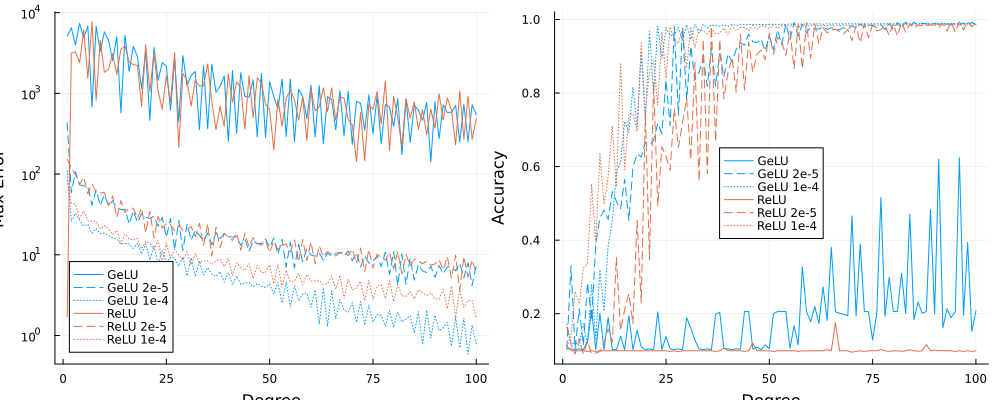

In [56]:
p_max_err = plot(degrees, max_errs_gelu, label="GeLU", xlabel="Degree", ylabel="Max Error", yscale=:log10, legend=:bottomleft, color=1)
plot!(degrees, max_errs_single, label="GeLU 2e-5", color=1, linestyle=:dash)
plot!(degrees, max_errs_gelu_1e4, label="GeLU 1e-4", color=1, linestyle=:dot)
plot!(degrees, max_errs_relu_standard, label="ReLU", color=2)
plot!(degrees, max_errs_relu_single, label="ReLU 2e-5", color=2, linestyle=:dash)
plot!(degrees, max_errs_relu_1e4, label="ReLU 1e-4", color=2, linestyle=:dot)

p_acc = plot(degrees, accs_gelu, label="GeLU", xlabel="Degree", ylabel="Accuracy", legend=:inside, color=1)
plot!(degrees, accs_single, label="GeLU 2e-5", color=1, linestyle=:dash)
plot!(degrees, accs_gelu_1e4, label="GeLU 1e-4", color=1, linestyle=:dot)
plot!(degrees, accs_relu_standard, label="ReLU", color=2)
plot!(degrees, accs_relu_single, label="ReLU 2e-5", color=2, linestyle=:dash)
plot!(degrees, accs_relu_1e4, label="ReLU 1e-4", color=2, linestyle=:dot)

plot(p_max_err, p_acc, layout=(1,2), size=(1000,400))

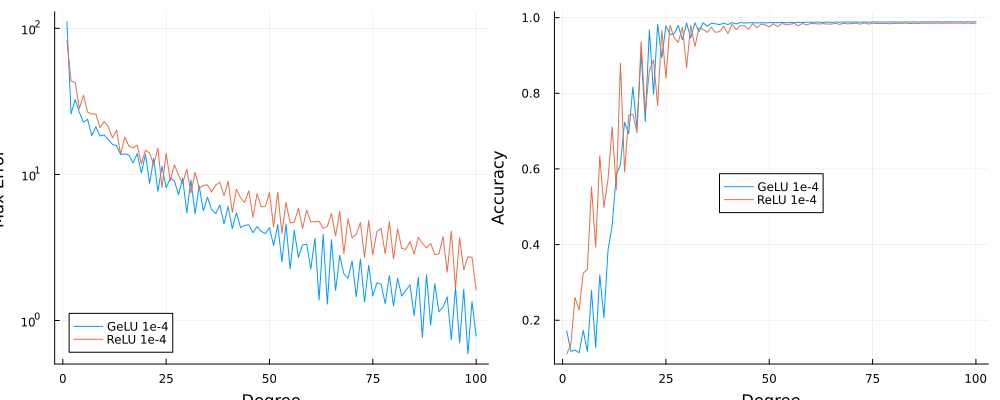

In [60]:
p_max_err = plot(degrees, max_errs_gelu_1e4, label="GeLU 1e-4", xlabel="Degree", ylabel="Max Error", yscale=:log10, legend=:bottomleft, color=1)
plot!(degrees, max_errs_relu_1e4, label="ReLU 1e-4", color=2)

p_acc = plot(degrees, accs_gelu_1e4, label="GeLU 1e-4", xlabel="Degree", ylabel="Accuracy", legend=:inside, color=1)
plot!(degrees, accs_relu_1e4, label="ReLU 1e-4", color=2)

plot(p_max_err, p_acc, layout=(1,2), size=(1000,400))

## Separate Polynomials

In [61]:
onnx_model = load_onnx_model("../networks/mnist/mnist_gelu_256x4_1e4_new.onnx")
nn_gelu_1e4_new = to_layered_model(onnx_model);
max_errs_gelu_1e4_new_polys, maes_gelu_1e4_new_polys, mses_gelu_1e4_new_polys, accs_gelu_1e4_new_polys = compute_approximation_stats(nn_gelu_1e4_new, degrees; max_polys_per_layer=Inf, max_iter=0, verbosity=0)

Original accuracy: 0.9903166666666666


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/qVmgT/src/network/layered_network.jl:21


Degree 1: max err = 47.41132064707483, mae = 35.453747802324884, mse = 3399.887085304714, acc = 0.1393
Degree 2: max err = 35.05029057080321, mae = 24.63027840170636, mse = 1412.637406235762, acc = 0.09736666666666667
Degree 3: max err = 26.999910520442974, mae = 16.64601095200871, mse = 861.124812980009, acc = 0.24873333333333333
Degree 4: max err = 25.389643994610374, mae = 16.694214113843667, mse = 676.317059407314, acc = 0.09961666666666667
Degree 5: max err = 19.674780843005877, mae = 12.429377466992666, mse = 338.6971588755055, acc = 0.4992333333333333
Degree 6: max err = 17.693428290635175, mae = 11.344451499728654, mse = 279.47319321891655, acc = 0.2748333333333333
Degree 7: max err = 16.95357949878346, mae = 10.580703568951582, mse = 254.99512556029268, acc = 0.5003
Degree 8: max err = 14.517803589650754, mae = 9.88797789401197, mse = 178.36127901763726, acc = 0.5826333333333333
Degree 9: max err = 15.731862126727366, mae = 9.298528456027805, mse = 171.72938171177327, acc = 0.

(Any[47.41132064707483, 35.05029057080321, 26.999910520442974, 25.389643994610374, 19.674780843005877, 17.693428290635175, 16.95357949878346, 14.517803589650754, 15.731862126727366, 13.392191657415609  …  0.31977797749872927, 0.26281783601050535, 0.2961808664074408, 0.26149703452161877, 0.24169429089053907, 0.21139209066817077, 0.23097140398977167, 0.1893519881666501, 0.2197414998271121, 0.1771928753011413], Any[35.453747802324884, 24.63027840170636, 16.64601095200871, 16.694214113843667, 12.429377466992666, 11.344451499728654, 10.580703568951582, 9.88797789401197, 9.298528456027805, 8.799333303800529  …  0.11402795001691847, 0.10187919543380652, 0.09920450750700126, 0.09764335708243357, 0.09162433926624138, 0.09286747654765697, 0.08874185998183974, 0.08558779684293162, 0.08947803885356063, 0.06968589692437542], Any[3399.887085304714, 1412.637406235762, 861.124812980009, 676.317059407314, 338.6971588755055, 279.47319321891655, 254.99512556029268, 178.36127901763726, 171.72938171177327,

In [62]:
onnx_model = load_onnx_model("../networks/mnist/mnist_256x4_1e4.onnx")
nn_relu_1e4 = to_layered_model(onnx_model);
max_errs_relu_1e4_polys, maes_relu_1e4_polys, mses_relu_1e4_polys, accs_relu_1e4_polys = compute_approximation_stats(nn_relu_1e4, degrees; max_polys_per_layer=Inf, max_iter=1, verbosity=0)

Original accuracy: 0.9864166666666667


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/qVmgT/src/network/layered_network.jl:21


Degree 1: max err = 52.25993976651153, mae = 39.72954095991325, mse = 5297.799923829021, acc = 0.14338333333333333
Degree 2: max err = 34.75169520469716, mae = 25.03146475850901, mse = 2433.5804090748447, acc = 0.23095
Degree 3: max err = 32.78689462637847, mae = 24.245084526679936, mse = 2229.874503255076, acc = 0.1565
Degree 4: max err = 23.486922765763985, mae = 16.38564767919101, mse = 829.7301909504997, acc = 0.37935
Degree 5: max err = 22.258859943007764, mae = 14.718837231550738, mse = 611.492276788164, acc = 0.3037666666666667
Degree 6: max err = 20.406583654219588, mae = 12.893631385303387, mse = 410.8113193310873, acc = 0.5872666666666667
Degree 7: max err = 18.399531450607824, mae = 12.282673631679947, mse = 365.8001413495444, acc = 0.4399166666666667
Degree 8: max err = 17.239924477798233, mae = 10.354641410337011, mse = 227.99825700346247, acc = 0.5818833333333333
Degree 9: max err = 16.13700163571637, mae = 10.474252118135512, mse = 237.11430724086136, acc = 0.59515
Degre

(Any[52.25993976651153, 34.75169520469716, 32.78689462637847, 23.486922765763985, 22.258859943007764, 20.406583654219588, 18.399531450607824, 17.239924477798233, 16.13700163571637, 14.32987445869925  …  0.9060670343567719, 1.1192215484643961, 1.0074757898341327, 0.9395333572686866, 1.0953961319127257, 1.0273240738960858, 0.9621985033533336, 1.0092372130632938, 0.9072198873962112, 0.8367874366092365], Any[39.72954095991325, 25.03146475850901, 24.245084526679936, 16.38564767919101, 14.718837231550738, 12.893631385303387, 12.282673631679947, 10.354641410337011, 10.474252118135512, 9.067055124208412  …  0.32490513231224916, 0.37710288354394905, 0.332473566849687, 0.32103681711293003, 0.35311871008894063, 0.3303207527183212, 0.321384870693837, 0.32395220965624194, 0.3212367263592976, 0.26775590850669034], Any[5297.799923829021, 2433.5804090748447, 2229.874503255076, 829.7301909504997, 611.492276788164, 410.8113193310873, 365.8001413495444, 227.99825700346247, 237.11430724086136, 176.5474571

In [63]:
onnx_model = load_onnx_model("../networks/mnist/mnist_gelu_256x4_1e4.onnx")
nn_gelu_1e4 = to_layered_model(onnx_model);
max_errs_gelu_1e4_polys, maes_gelu_1e4_polys, mses_gelu_1e4_polys, accs_gelu_1e4_polys = compute_approximation_stats(nn_gelu_1e4, degrees; max_polys_per_layer=Inf, max_iter=0, verbosity=0)

Original accuracy: 0.9893


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/qVmgT/src/network/layered_network.jl:21


Degree 1: max err = 40.85047860643751, mae = 27.383588218563165, mse = 2390.8888071637502, acc = 0.11825
Degree 2: max err = 28.716910212467027, mae = 18.15193856184339, mse = 798.4914494576302, acc = 0.11236666666666667
Degree 3: max err = 33.32998469787813, mae = 17.834028965762062, mse = 814.4880856927109, acc = 0.27191666666666664
Degree 4: max err = 23.742004338052386, mae = 14.044484920201983, mse = 418.44391348449756, acc = 0.32293333333333335
Degree 5: max err = 28.197955565738322, mae = 13.850328102822463, mse = 447.201974106758, acc = 0.15173333333333333
Degree 6: max err = 19.001547545961806, mae = 11.8192884564454, mse = 267.5254660010103, acc = 0.3667166666666667
Degree 7: max err = 21.250357025167595, mae = 10.923889050655857, mse = 270.70573710185243, acc = 0.29851666666666665
Degree 8: max err = 18.923629714642658, mae = 10.536466187887815, mse = 192.4236819499608, acc = 0.5464333333333333
Degree 9: max err = 15.602398845547665, mae = 8.916053701734594, mse = 151.403953

(Any[40.85047860643751, 28.716910212467027, 33.32998469787813, 23.742004338052386, 28.197955565738322, 19.001547545961806, 21.250357025167595, 18.923629714642658, 15.602398845547665, 18.40866091783432  …  0.4555041147466048, 0.3985088334725413, 0.4416413682708492, 0.41593070803155996, 0.38121489889728366, 0.38053975450782423, 0.3298796869653762, 0.3908394334508367, 0.3347782121083922, 0.2910372605102367], Any[27.383588218563165, 18.15193856184339, 17.834028965762062, 14.044484920201983, 13.850328102822463, 11.8192884564454, 10.923889050655857, 10.536466187887815, 8.916053701734594, 9.598452345413879  …  0.18280324788589156, 0.18616804752588997, 0.1776917254216202, 0.1653261075334554, 0.17313314563639082, 0.15262026003830872, 0.15526440568023184, 0.14296789227100223, 0.1456954839376996, 0.13150963205507252], Any[2390.8888071637502, 798.4914494576302, 814.4880856927109, 418.44391348449756, 447.201974106758, 267.5254660010103, 270.70573710185243, 192.4236819499608, 151.40395396162214, 169

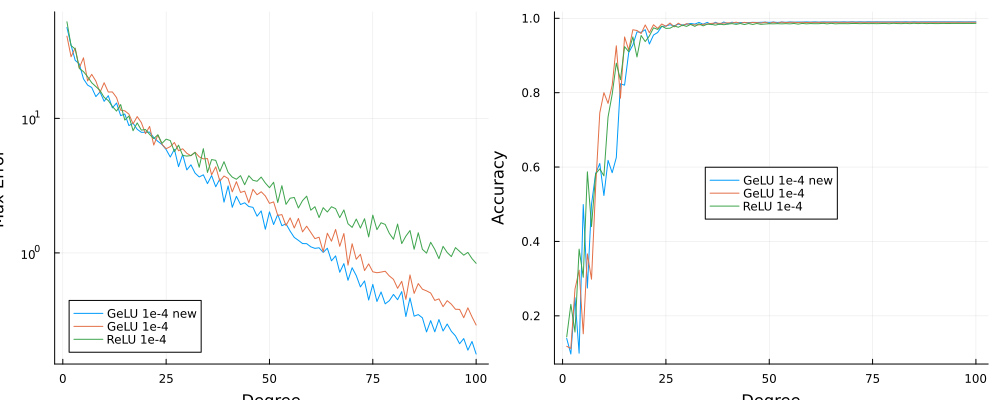

In [64]:
p_max_err = plot(degrees, max_errs_gelu_1e4_new_polys, label="GeLU 1e-4 new", xlabel="Degree", ylabel="Max Error", yscale=:log10, legend=:bottomleft, color=1)
plot!(degrees, max_errs_gelu_1e4_polys, label="GeLU 1e-4", color=2)
plot!(degrees, max_errs_relu_1e4_polys, label="ReLU 1e-4", color=3)

p_acc = plot(degrees, accs_gelu_1e4_new_polys, label="GeLU 1e-4 new", xlabel="Degree", ylabel="Accuracy", legend=:inside, color=1)
plot!(degrees, accs_gelu_1e4_polys, label="GeLU 1e-4", color=2)
plot!(degrees, accs_relu_1e4_polys, label="ReLU 1e-4", color=3)

plot(p_max_err, p_acc, layout=(1,2), size=(1000,400))

# Effect of Remez vs Chebyshev

In [65]:
onnx_model = load_onnx_model("../networks/mnist/mnist_256x4_1e4.onnx")
nn_relu_1e4 = to_layered_model(onnx_model);
max_errs_relu_1e4_remez, maes_relu_1e4_remez, mses_relu_1e4_remez, accs_relu_1e4_remez = compute_approximation_stats(nn_relu_1e4, degrees; max_polys_per_layer=Inf, max_iter=20, verbosity=0)

Original accuracy: 0.9864166666666667


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/qVmgT/src/network/layered_network.jl:21


Degree 1: max err = 43.955367067967316, mae = 31.06429666762878, mse = 3152.460283141473, acc = 0.17158333333333334
Degree 2: max err = 28.89065820938184, mae = 19.61944470693981, mse = 1210.4756963066732, acc = 0.15133333333333332
Degree 3: max err = 22.61390879134009, mae = 14.767355138420573, mse = 554.612221877655, acc = 0.3928333333333333
Degree 4: max err = 17.711996124257354, mae = 11.821677675298773, mse = 277.8573305405739, acc = 0.4567
Degree 5: max err = 14.565118933588106, mae = 9.732071775379847, mse = 169.02939916986924, acc = 0.8107666666666666
Degree 6: max err = 13.382270757315524, mae = 9.051182813309412, mse = 148.00481018325638, acc = 0.8269333333333333
Degree 7: max err = 12.334020741407578, mae = 8.266187887981992, mse = 125.19478368998227, acc = 0.9091166666666667
Degree 8: max err = 11.256163960508982, mae = 7.385372856472827, mse = 105.74997743300287, acc = 0.9384333333333333
Degree 9: max err = 10.262942504041334, mae = 6.670632534330955, mse = 90.781609324282

(Any[43.955367067967316, 28.89065820938184, 22.61390879134009, 17.711996124257354, 14.565118933588106, 13.382270757315524, 12.334020741407578, 11.256163960508982, 10.262942504041334, 9.713366902171714  …  0.9476064842614011, 0.9383276859125518, 0.9083629207512889, 0.9041995375654874, 0.8834033228508922, 0.8755105678006547, 0.8850120016558076, 0.8676446832424514, 0.8696989144140161, 0.9034357985637911], Any[31.06429666762878, 19.61944470693981, 14.767355138420573, 11.821677675298773, 9.732071775379847, 9.051182813309412, 8.266187887981992, 7.385372856472827, 6.670632534330955, 6.139376503122245  …  0.301530415325339, 0.29743416341920986, 0.2941713114144928, 0.29074435353022926, 0.2874719698290343, 0.28415056149040935, 0.2813007927457267, 0.27776777831912464, 0.2754537021541553, 0.27216370094198167], Any[3152.460283141473, 1210.4756963066732, 554.612221877655, 277.8573305405739, 169.02939916986924, 148.00481018325638, 125.19478368998227, 105.74997743300287, 90.78160932428247, 80.22175126

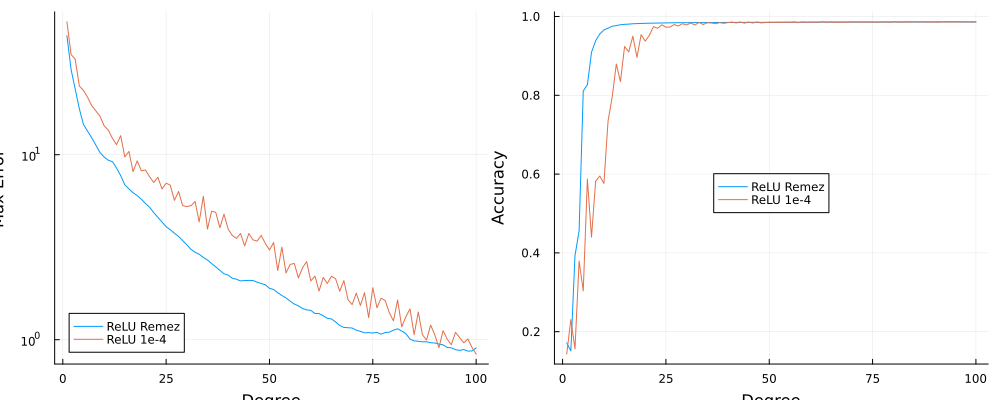

In [66]:
p_max_err = plot(degrees, max_errs_relu_1e4_remez, label="ReLU Remez", xlabel="Degree", ylabel="Max Error", yscale=:log10, legend=:bottomleft, color=1)
plot!(degrees, max_errs_relu_1e4_polys, label="ReLU 1e-4", color=2)

p_acc = plot(degrees, accs_relu_1e4_remez, label="ReLU Remez", xlabel="Degree", ylabel="Accuracy", legend=:inside, color=1)
plot!(degrees, accs_relu_1e4_polys, label="ReLU 1e-4", color=2)

plot(p_max_err, p_acc, layout=(1,2), size=(1000,400))

# Comparison of Intermediate Bounds

In [67]:
onnx_model = load_onnx_model("../networks/mnist/mnist_256x4_2e5.onnx")
nn_relu_2e5 = to_layered_model(onnx_model);

onnx_model = load_onnx_model("../networks/mnist/mnist_gelu_256x4_2e5.onnx")
nn_gelu_2e5 = to_layered_model(onnx_model);

┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/qVmgT/src/network/layered_network.jl:21
┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/qVmgT/src/network/layered_network.jl:21


In [68]:
degree = 30
nn_relu_poly_degree = approximate_polynomial_iterative(nn_relu_2e5, Zonotope(zeros(784), ones(784)), degree, max_polys_per_layer=Inf, verbosity=0, max_iter=1)
nn_gelu_poly_degree = approximate_polynomial_iterative(nn_gelu_2e5, Zonotope(zeros(784), ones(784)), degree, max_polys_per_layer=Inf, verbosity=0, max_iter=0)

LayeredModel{String}(VNNLib.OnnxParser.Node{String}[VNNLib.OnnxParser.ONNXLinear{String}(["/flatten/Flatten_output_0"], ["/input/Gemm_output_0"], "/input/Gemm", Dense(784 => 256), false), ONNXChebyshevPoly{String, Float64, SubArray{Float64, 1, Matrix{Float64}, Tuple{Base.Slice{Base.OneTo{Int64}}, Int64}, true}}(["/input/Gemm_output_0"], ["/gelu0/Gelu_output_0"], "/gelu0/Gelu", [-0.0009327578442441503 0.015810136988927047 … 1.2374360795301223e-17 -1.1564823173178714e-19; -0.0006835049633530081 0.20879349238625758 … 8.326672684688674e-18 -3.7007434154171884e-18; … ; 0.002040443606517134 0.012955253981921135 … 1.0466164971726736e-17 0.0; 0.16890797103922453 0.20565500517131113 … 1.7821392509868398e-16 1.7347234759768072e-19], [-0.03400663680804428, -1.615152710628081, -0.03224337067831584, -18.543636514199306, -13.88411422771469, -15.44826650041432, -8.438691076662735, -16.735757474025036, -16.021036611457248, -11.901667568891298  …  -0.031275922913664544, -0.028307259819939645, -0.378271

In [167]:
n_layers = 4

lbs_gelu = []
lbs_relu = []

ubs_gelu = []
ubs_relu = []

for i in 1:n_layers-1
    idx = 2*i 
    push!(lbs_relu, nn_relu_poly_degree.layers[idx].l...)
    push!(lbs_gelu, nn_gelu_poly_degree.layers[idx].l...)
    push!(ubs_relu, nn_relu_poly_degree.layers[idx].u...)
    push!(ubs_gelu, nn_gelu_poly_degree.layers[idx].u...)
end

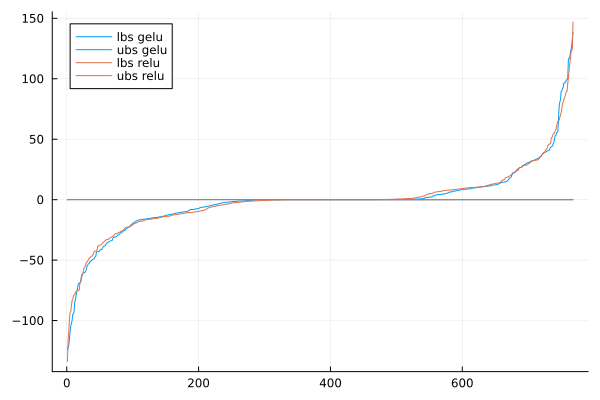

In [168]:
plot(sort(lbs_gelu), label="lbs gelu", color=1)
plot!(sort(ubs_gelu), label="ubs gelu", color=1)
plot!(sort(lbs_relu), label="lbs relu", color=2)
plot!(sort(ubs_relu), label="ubs relu", color=2)

In [169]:
widths_gelu = ubs_gelu .- lbs_gelu
perm_gelu = sortperm(widths_gelu)

widths_relu = ubs_relu .- lbs_relu 
perm_relu = sortperm(widths_relu);

# Investigate GeLU Performance

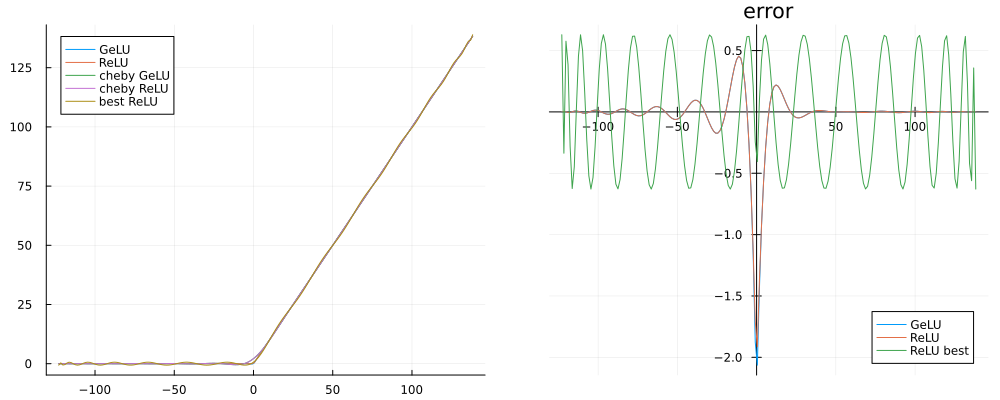

In [170]:
idx = 768
l = lbs_gelu[perm_gelu][idx]
u = ubs_gelu[perm_gelu][idx]

gelu = x -> 0.5 * x * (1 + erf(x / sqrt(2)))

p = VeryDiff.chebyshev_coefficients(gelu, l, u, degree)
pfun = x -> VeryDiff.clenshaw_chebyshev(p, x, l, u)

q = VeryDiff.chebyshev_coefficients(x -> max(0, x), l, u, degree)
qfun = x -> VeryDiff.clenshaw_chebyshev(q, x, l, u)

q_best, _ = VeryDiff.approx_relu_poly(l, u, degree, max_iter=20)
q_best_fun = x -> VeryDiff.clenshaw_chebyshev(q_best, x, l, u)

errfun_gelu = x -> gelu(x) - pfun(x)
errfun_relu = x -> max(0, x) - qfun(x)
errfun_relu_best = x -> max(0, x) - q_best_fun(x)

xs = range(l, u, 200)
p1 = plot(xs, gelu.(xs), label="GeLU")
plot!(xs, max.(0, xs), label="ReLU")
plot!(xs, pfun.(xs), label="cheby GeLU")
plot!(xs, qfun.(xs), label="cheby ReLU")
plot!(xs, q_best_fun.(xs), label="best ReLU")


p2 = plot(xs, errfun_gelu.(xs), label="GeLU", framestyle=:origin, title="error")
plot!(xs, errfun_relu.(xs), label="ReLU")
plot!(xs, errfun_relu_best.(xs), label="ReLU best")

plot(p1, p2, size=(1000, 400))

Hypothesis: While `GeLU` has a better overall error, the error for `ReLU` is large at $x = 0$, but small outside of that range.

So it would still help for *verification*, but when it comes to actual performance of the FHE network, it is very unlikely to have inputs this close to $0$ for the `ReLU` function.

**Why is Remez better** for ReLU? The Error is worse almost everywhere?

In [118]:
nn_relu_partial = LayeredModel(nn_relu_poly_degree.layers[1:end-2])
nn_gelu_partial = LayeredModel(nn_gelu_poly_degree.layers[1:end-2])

LayeredModel{String}(VNNLib.OnnxParser.Node{String}[VNNLib.OnnxParser.ONNXLinear{String}(["/flatten/Flatten_output_0"], ["/input/Gemm_output_0"], "/input/Gemm", Dense(784 => 256), false), ONNXChebyshevPoly{String, Float64, SubArray{Float64, 1, Matrix{Float64}, Tuple{Base.Slice{Base.OneTo{Int64}}, Int64}, true}}(["/input/Gemm_output_0"], ["/gelu0/Gelu_output_0"], "/gelu0/Gelu", [-0.0009327578442441503 0.015810136988927047 … 1.2374360795301223e-17 -1.1564823173178714e-19; -0.0006835049633530081 0.20879349238625758 … 8.326672684688674e-18 -3.7007434154171884e-18; … ; 0.002040443606517134 0.012955253981921135 … 1.0466164971726736e-17 0.0; 0.16890797103922453 0.20565500517131113 … 1.7821392509868398e-16 1.7347234759768072e-19], [-0.03400663680804428, -1.615152710628081, -0.03224337067831584, -18.543636514199306, -13.88411422771469, -15.44826650041432, -8.438691076662735, -16.735757474025036, -16.021036611457248, -11.901667568891298  …  -0.031275922913664544, -0.028307259819939645, -0.378271

In [121]:
ŷ_relu = [nn_relu_partial(x) for x in X_test]
ŷ_relu = hcat(ŷ_relu...)'

ŷ_gelu = [nn_gelu_partial(x) for x in X_test]
ŷ_gelu = hcat(ŷ_gelu...)';

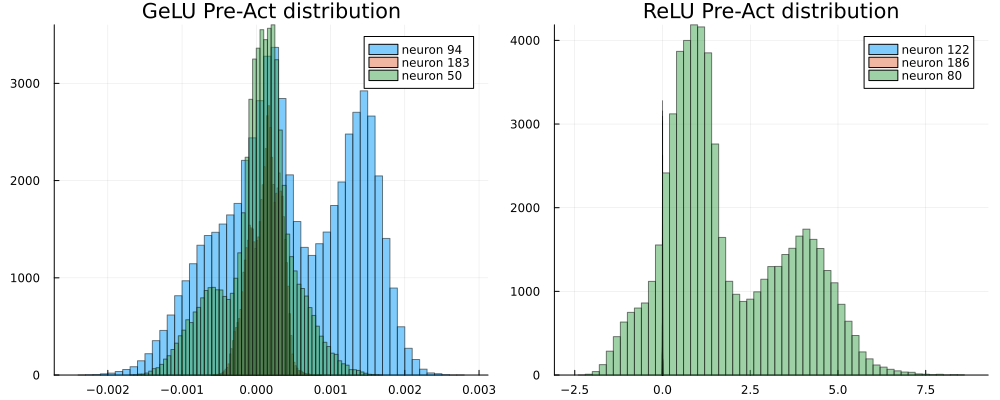

In [153]:
n_plot = 3

p1 = histogram(title="GeLU Pre-Act distribution")
for i in 1:n_plot
    ind = rand(1:256)
    histogram!(ŷ_gelu[:,ind], label="neuron $ind", alpha=0.5) 
end

p2 = histogram(title="ReLU Pre-Act distribution")
for i in 1:n_plot
    ind = rand(1:256)
    histogram!(ŷ_relu[:,ind], label="neuron $ind", alpha=0.5) 
end

plot(p1, p2, size=(1000, 400))

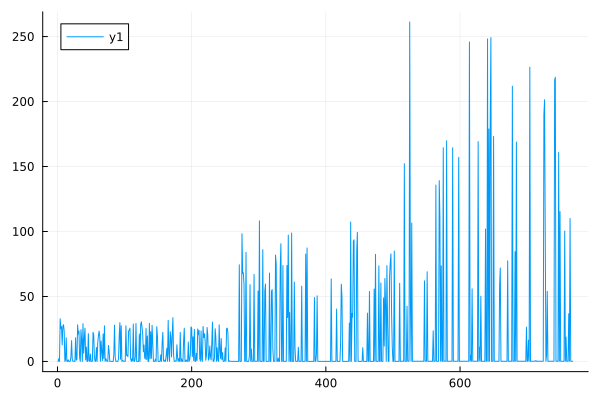

In [171]:
plot(widths_gelu)

In [166]:
nn_gelu_poly_degree.layers[6].l

256-element view(::Matrix{Float64}, :, 1) with eltype Float64:
  -0.07886831713521399
  -0.06572288785027401
  -0.08386967257211635
  -0.10675884547096545
 -84.8167022965343
  -0.07024375656944094
  -0.023824822987989134
  -0.06962528417144631
 -20.83536611502746
  -0.102880672480025
   ⋮
  -0.09033537832384224
  -0.05760073229233746
 -14.37763615757318
  -0.07873003771902495
 -54.36523967859687
  -0.10676758019705403
  -0.079891380391871
  -0.07828541275499355
  -0.06726620911264215

In [126]:
# index of the neuron in the 4th layer pre-activation
idx4 = perm_gelu[idx] - 256*2

ŷ[:,idx4]

60000-element Vector{Float64}:
 -0.8886231792135182
  1.4106872266731048
  1.151671984385421
  0.8097946020105998
  0.022747241377070737
  1.1090216274718498
  0.9428667130804861
 -1.2611462447049175
  0.4610924593228059
  1.8025953991344597
  ⋮
  1.6111750347704183
  0.24524959379774075
  0.20067788059458574
  0.8296646237492432
  1.5688154946758144
 -0.457209635262135
 -0.4767987862693446
  1.8832822359824473
  1.275570189725588

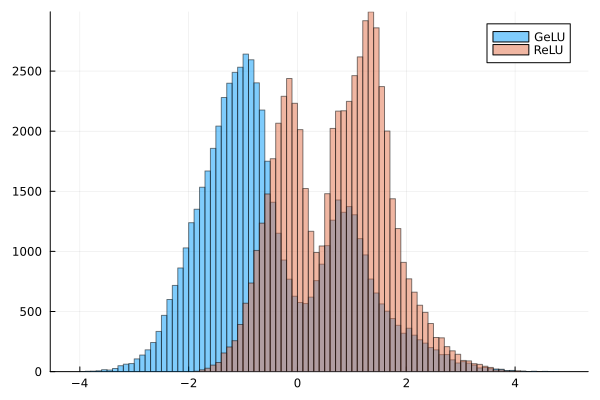

In [127]:
histogram(ŷ_gelu[:,idx4], label="GeLU", alpha=0.5)
histogram!(ŷ_relu[:,idx4], label="ReLU", alpha=0.5)

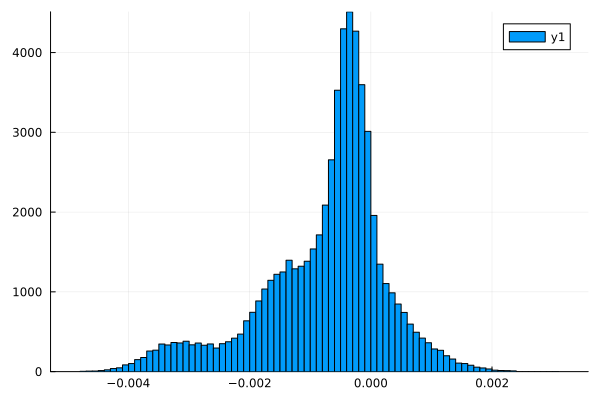

In [130]:
histogram(ŷ_relu[:,idx4_relu])

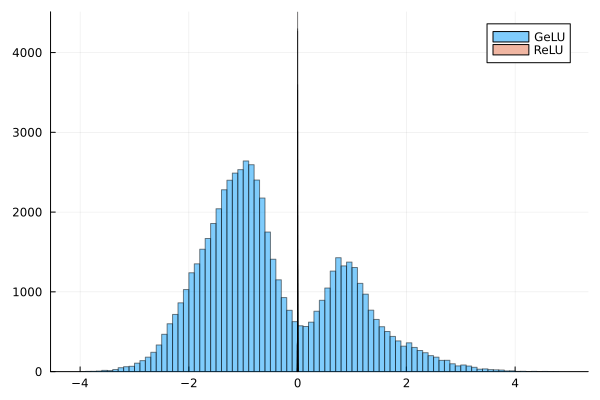

In [ ]:
idx4_gelu = perm_gelu[idx] - 256*2
idx4_relu = perm_relu[idx] - 256*2

histogram(ŷ_gelu[:,idx4_gelu], label="GeLU", alpha=0.5)
histogram!(ŷ_relu[:,idx4_relu], label="ReLU", alpha=0.5)

In [172]:
function make_error_function(f, l, u, degree; mode=:chebyshev)
    if mode == :chebyshev 
        p = VeryDiff.chebyshev_coefficients(f, l, u, degree)
    elseif mode == :remez
        p, _ = VeryDiff.approx_relu_poly(l, u, degree, max_iter=20)
    else
        throw(ArgumentError("Mode $mode not known!"))
    end

    pfun = x -> VeryDiff.clenshaw_chebyshev(p, x, l, u)
    errfun = x -> f(x) - pfun(x)
end

function total_error(f, l, u, xs, degree; mode=:chebyshev)
    errfun = make_error_function(f, l, u, degree, mode=mode)
    sum(abs.(errfun.(xs)))
end

total_error (generic function with 2 methods)

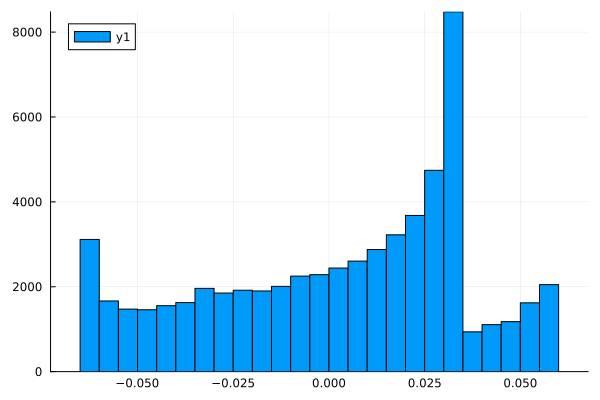

In [142]:
gelu_error = make_error_function(gelu, lbs_gelu[perm_gelu[idx]], ubs_gelu[perm_gelu[idx]], ŷ_gelu[:,idx4_gelu], 30, mode=:chebyshev)

ŷ_gelu_error = gelu_error.(ŷ_gelu[:,idx4_gelu])

histogram(ŷ_gelu_error)

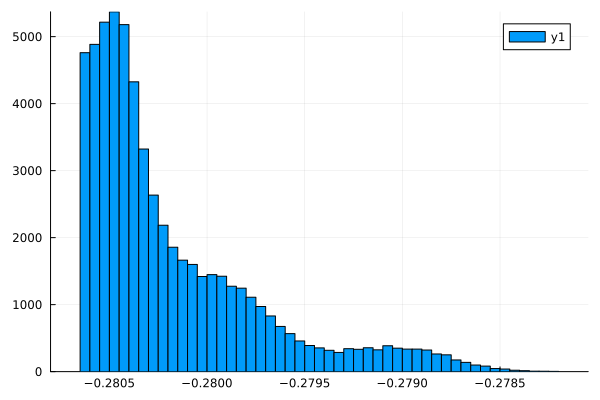

In [143]:
relu_error = make_error_function(x -> max(0, x), lbs_relu[perm_relu[idx]], ubs_relu[perm_relu[idx]], ŷ_relu[:,idx4_relu], 30, mode=:chebyshev)

ŷ_relu_error = relu_error.(ŷ_relu[:,idx4_relu])

histogram(ŷ_relu_error)

In [138]:
total_error(x -> max(0, x), lbs_relu[perm_relu[idx]], ubs_relu[perm_relu[idx]], ŷ_relu[:,idx4_relu], 30, mode=:chebyshev)

16810.746987359336

In [139]:
total_error(x -> max(0, x), lbs_relu[perm_relu[idx]], ubs_relu[perm_relu[idx]], ŷ_relu[:,idx4_relu], 30, mode=:remez)

4872.566180703821

In [140]:
total_error(gelu, lbs_gelu[perm_gelu[idx]], ubs_gelu[perm_gelu[idx]], ŷ_gelu[:,idx4_gelu], 30, mode=:chebyshev)

1753.012386611916

## Connection to Bounds

In [201]:
sampled_bounds_relu = VeryDiffPolyExperiments.get_empirical_bounds(nn_relu_poly_degree, X_test)
sampled_bounds_gelu = VeryDiffPolyExperiments.get_empirical_bounds(nn_gelu_poly_degree, X_test);

In [214]:
n_layers = 4

lbs_gelu = []
lbs_relu = []

ubs_gelu = []
ubs_relu = []

lbs_gelu_sampled = []
lbs_relu_sampled = []

ubs_gelu_sampled = []
ubs_relu_sampled = []

for i in 1:n_layers
    idx = 2*i 
    push!(lbs_relu, nn_relu_poly_degree.layers[idx].l...)
    push!(lbs_gelu, nn_gelu_poly_degree.layers[idx].l...)
    push!(ubs_relu, nn_relu_poly_degree.layers[idx].u...)
    push!(ubs_gelu, nn_gelu_poly_degree.layers[idx].u...)

    push!(lbs_relu_sampled, sampled_bounds_relu[idx][:,1]...)
    push!(lbs_gelu_sampled, sampled_bounds_gelu[idx][:,1]...)
    push!(ubs_relu_sampled, sampled_bounds_relu[idx][:,2]...)
    push!(ubs_gelu_sampled, sampled_bounds_gelu[idx][:,2]...)
end

In [215]:
widths_gelu = ubs_gelu .- lbs_gelu
widths_relu = ubs_relu .- lbs_relu 
widths_gelu_sampled = ubs_gelu_sampled .- lbs_gelu_sampled
widths_relu_sampled = ubs_relu_sampled .- lbs_relu_sampled;

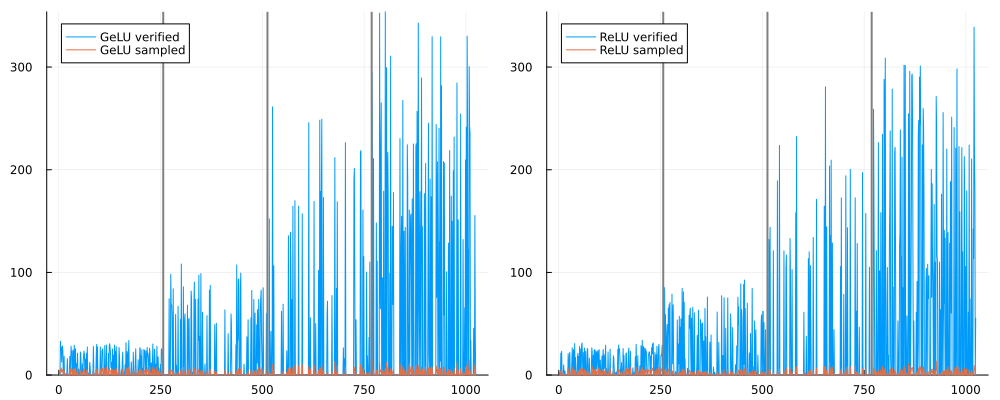

In [222]:
y_max = max(maximum(widths_gelu), maximum(widths_relu))

p1 = plot(widths_gelu, label="GeLU verified")
plot!(widths_gelu_sampled, label="GeLU sampled")
vline!([256.5, 2*256 + 0.5, 3*256 + 0.5], label=nothing, color=:gray, lw=2)
ylims!(0, y_max)

p2 = plot(widths_relu, label="ReLU verified")
plot!(widths_relu_sampled, label="ReLU sampled")
vline!([256.5, 2*256 + 0.5, 3*256 + 0.5], label=nothing, color=:gray, lw=2)
ylims!(0, y_max)

plot(p1, p2, size=(1000, 400))

In [227]:
println("Layer 1")
println("\trelu - verified: ", maximum(widths_relu[1:256]), ", sampled: ", maximum(widths_relu_sampled[1:256]))
println("\tgelu - verified: ", maximum(widths_gelu[1:256]), ", sampled: ", maximum(widths_gelu_sampled[1:256]))

println("Layer 2")
println("\trelu - verified: ", maximum(widths_relu[256+1:2*256]), ", sampled: ", maximum(widths_relu_sampled[256+1:2*256]))
println("\tgelu - verified: ", maximum(widths_gelu[256+1:2*256]), ", sampled: ", maximum(widths_gelu_sampled[256+1:2*256]))

println("Layer 3")
println("\trelu - verified: ", maximum(widths_relu[2*256+1:3*256]), ", sampled: ", maximum(widths_relu_sampled[2*256+1:3*256]))
println("\tgelu - verified: ", maximum(widths_gelu[2*256+1:3*256]), ", sampled: ", maximum(widths_gelu_sampled[2*256+1:3*256]))

println("Layer 4")
println("\trelu - verified: ", maximum(widths_relu[3*256+1:end]), ", sampled: ", maximum(widths_relu_sampled[3*256+1:end]))
println("\tgelu - verified: ", maximum(widths_gelu[3*256+1:end]), ", sampled: ", maximum(widths_gelu_sampled[3*256+1:end]))


Layer 1
	relu - verified: 33.88399171058728, sampled: 8.463335734694748
	gelu - verified: 33.686564200112116, sampled: 8.603299645440327
Layer 2
	relu - verified: 92.54556952999798, sampled: 7.240918646788803
	gelu - verified: 108.15507278699955, sampled: 7.439454064221048
Layer 3
	relu - verified: 280.7472595297882, sampled: 12.162687547445366
	gelu - verified: 261.2154757237727, sampled: 13.250652624231911
Layer 4
	relu - verified: 338.8229122313155, sampled: 13.69863203710291
	gelu - verified: 353.8218459053612, sampled: 14.754367395214857


In [230]:
"""
Computes error for polynomial approximation over domain [-r, r] for n_samples radii in the interval [l_radius, u_radius] for ReLU Chebyshev approximation,
ReLU Remez approximation and GeLU Chebyshev approximation.

args:
    u_radius - upper bound of the radius 
    degree - degree of the polynomial approximation 

kwargs:
    n_samples - radius samples 
    l_radius - lower bound of the radius 
    err_radius - if err_radius > 0, then we return the error inside [-err_radius, err_radius]
    err_mode - :max if we want maximum error, :avg if we want average error
"""
function make_error_curves(u_radius, degree; n_samples=200, l_radius=1., err_radius=-1, err_mode=:max, n_err_samples=1000)
    @assert u_radius > l_radius "l_radius is $(l_radius), so u_radius has to be larger than that!"
    radii = range(l_radius, u_radius, n_samples)
    errs_relu = []
    errs_relu_best = []
    errs_gelu = []
    for r in radii
        l, u = -r, r 

        relu_error = make_error_function(x -> max(0, x), l, u, degree, mode=:chebyshev)
        relu_error_best = make_error_function(x -> max(0, x), l, u, degree, mode=:remez)
        gelu_error = make_error_function(gelu, l, u, degree, mode=:chebyshev)

        if err_radius > 0
            xs = range(-err_radius, err_radius, n_err_samples)
        else
            xs = range(l, u, n_err_samples)
        end

        if err_mode == :max
            ϵ_relu = maximum(abs.(relu_error.(xs)))
            ϵ_relu_best = maximum(abs.(relu_error_best.(xs)))
            ϵ_gelu = maximum(abs.(gelu_error.(xs)))
        elseif err_mode == :avg 
            ϵ_relu = sum(abs.(relu_error.(xs))) / n_err_samples
            ϵ_relu_best = sum(abs.(relu_error_best.(xs))) / n_err_samples
            ϵ_gelu = sum(abs.(gelu_error.(xs))) / n_err_samples
        else 
            throw(ArgumentError("Unknown err_mode $(err_mode)!"))
        end

        push!(errs_relu, ϵ_relu)
        push!(errs_relu_best, ϵ_relu_best)
        push!(errs_gelu, ϵ_gelu)
    end

    radii, errs_relu, errs_relu_best, errs_gelu
end

make_error_curves

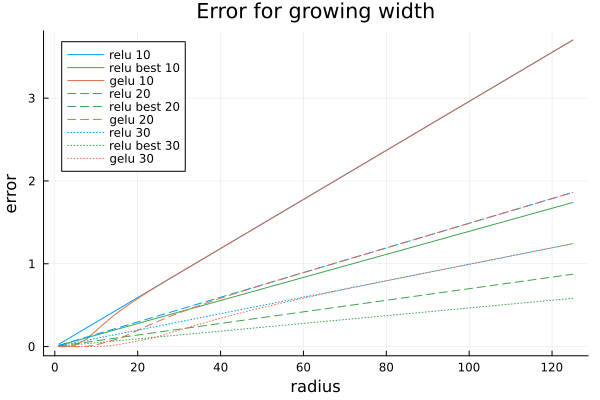

In [199]:
p1 = plot(title="Error for growing width", xlabel="radius", ylabel="error")
for (degree, ls) in zip([10, 20, 30], [:solid, :dash, :dot])
    radii, errs_relu, errs_relu_best, errs_gelu = make_error_curves(125, degree)

    plot!(radii, errs_relu, label="relu $degree", color=1, linestyle=ls)
    plot!(radii, errs_relu_best, label="relu best $degree", color=3, linestyle=ls)
    plot!(radii, errs_gelu, label="gelu $degree", color=2, linestyle=ls)
end

p1

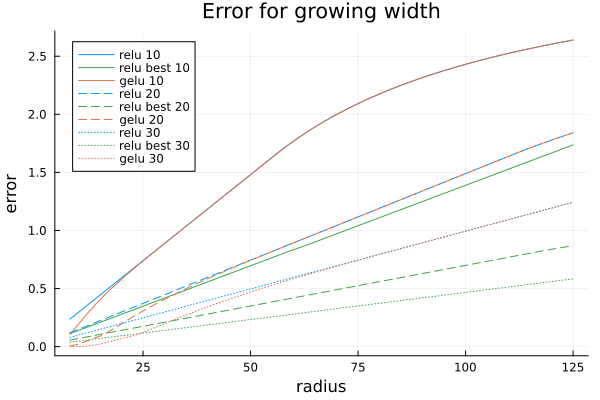

In [229]:
p1 = plot(title="Error for growing width", xlabel="radius", ylabel="error")
for (degree, ls) in zip([10, 20, 30], [:solid, :dash, :dot])
    radii, errs_relu, errs_relu_best, errs_gelu = make_error_curves(125, degree, l_radius=8., err_radius=7.)

    plot!(radii, errs_relu, label="relu $degree", color=1, linestyle=ls)
    plot!(radii, errs_relu_best, label="relu best $degree", color=3, linestyle=ls)
    plot!(radii, errs_gelu, label="gelu $degree", color=2, linestyle=ls)
end

p1

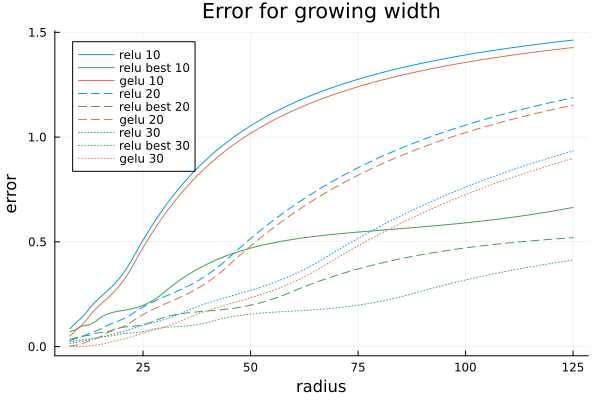

In [231]:
p1 = plot(title="Error for growing width", xlabel="radius", ylabel="error")
for (degree, ls) in zip([10, 20, 30], [:solid, :dash, :dot])
    radii, errs_relu, errs_relu_best, errs_gelu = make_error_curves(125, degree, l_radius=8., err_radius=7., err_mode=:avg)

    plot!(radii, errs_relu, label="relu $degree", color=1, linestyle=ls)
    plot!(radii, errs_relu_best, label="relu best $degree", color=3, linestyle=ls)
    plot!(radii, errs_gelu, label="gelu $degree", color=2, linestyle=ls)
end

p1